In [11]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install pyg_lib --no-index -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
import torch
import random
from IPython.display import HTML
import sys
from sklearn.manifold import TSNE
!pip install -q torch-geometric -f https://data.pyg.org/whl/torch-{torch_version}.html
import torch_geometric
from torch_geometric.datasets import MalNetTiny
import torch_geometric.transforms as T
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import json
from torch_geometric.utils import to_dense_adj
from torch_geometric.nn import Node2Vec, GCNConv, GATConv
from sklearn.cluster import KMeans
import community as community_louvain
from torch_geometric.utils import to_networkx
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix


%matplotlib inline

# Configuración de la semilla para reproducibilidad
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


# **IMPORTACIÓN Y VISUALIZACIÓN DE LA DATA**

In [10]:
dataset = MalNetTiny(root='data/MalNet')

data = dataset[0]
print(f'Dataset: {dataset}:')
print('======================')
print(f'Número de nodos: {data.num_nodes}')
print(f'Número de aristas: {data.num_edges}')
print(f'Número de clases: {dataset.num_classes}')
print(f'Dimensión de características: {dataset.num_features}')

Dataset: MalNetTiny(5000):
Número de nodos: 1679
Número de aristas: 3576
Número de clases: 5
Dimensión de características: 0


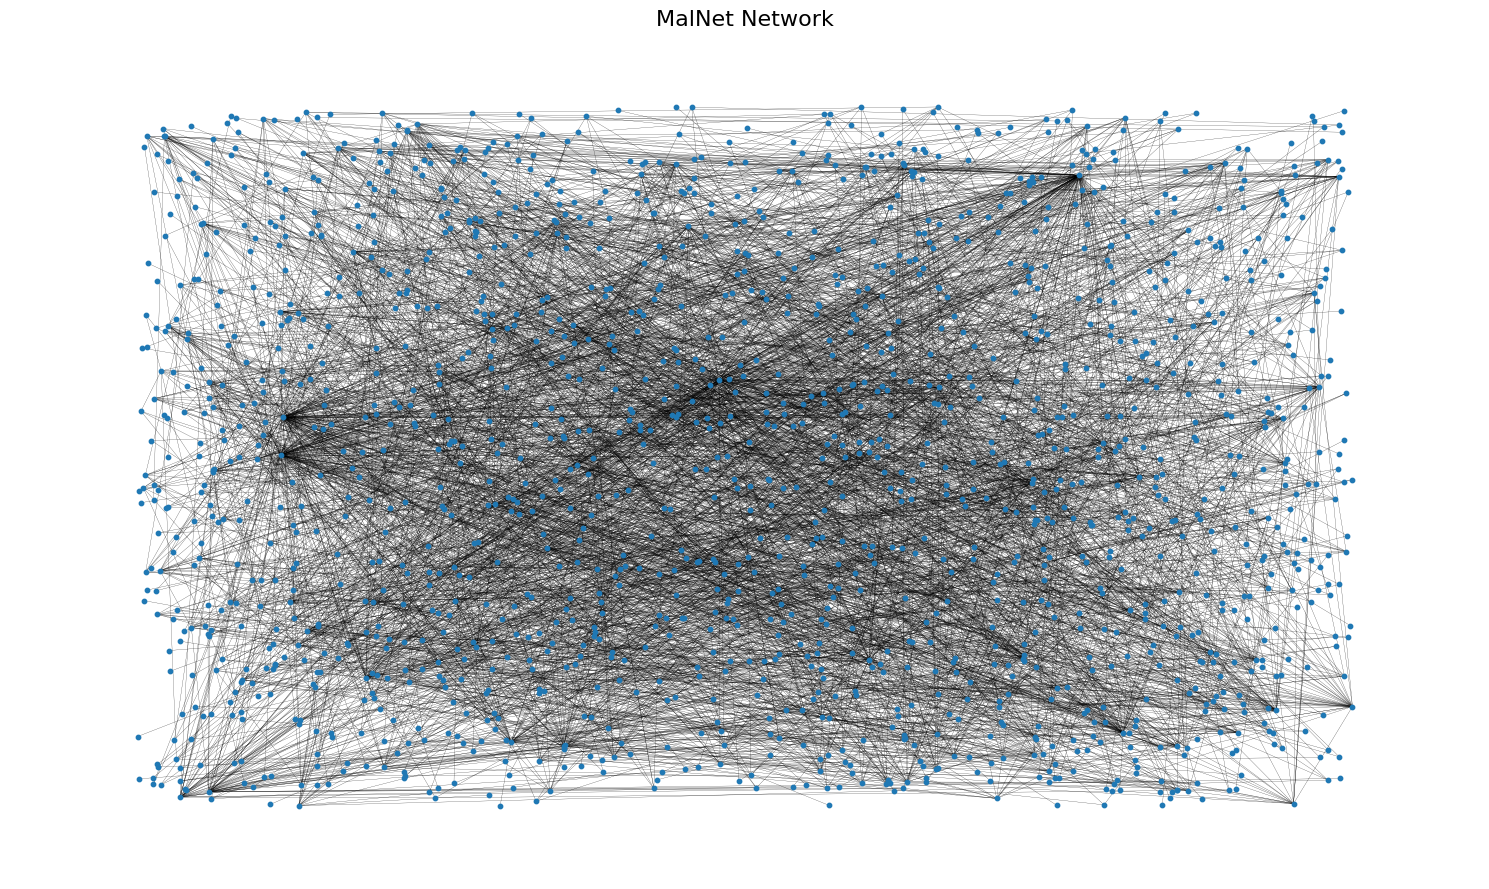

In [ ]:
edge_index_list = pd.DataFrame(data.edge_index.numpy().T, columns=['start_node','end_node'])

G = nx.from_pandas_edgelist(edge_index_list, "start_node", "end_node")

fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")

plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}

nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)
plt.title("MalNet Network", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
nodes_data = []
for node_id in range(min(5000, data.num_nodes)):
    if node_id < len(data.y):
        group = int(data.y[node_id].item())
    else:
        group = 0

    nodes_data.append({
        "id": str(node_id),
        "group": group
    })

edges_data = []
for edge in edge_index_list.values:
    source, target = edge
    if source < 5000 and target < 5000:
        edges_data.append({
            "source": str(source),
            "target": str(target)
        })

graph_data = {
    "nodes": nodes_data,
    "links": edges_data
}

graph_json = json.dumps(graph_data)

html_code = f"""
<!DOCTYPE html>
<html>
<head>
    <style> body {{ margin: 0; }} </style>
    <script src="https://unpkg.com/3d-force-graph@1.70.5/dist/3d-force-graph.min.js"></script>
</head>
<body>
    <div id="3d-graph" style="width: 100%; height: 600px;"></div>

    <script>
        // Parse the data
        const graphData = {graph_json};

        // Node colors based on group
        const colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'];

        // Initialize the 3D force graph
        const Graph = ForceGraph3D()
            (document.getElementById('3d-graph'))
            .graphData(graphData)
            .nodeColor(node => colors[node.group % colors.length])
            .nodeRelSize(3)
            .linkWidth(0.2)
            .linkOpacity(0.5)
            .backgroundColor('#FFFFFF')
            .nodeLabel(node => `Node ${{node.id}}`)
            .linkDirectionalParticles(1)
            .linkDirectionalParticleWidth(0.5)
            .enableNodeDrag(true)
            .enableNavigationControls(true)
            .showNavInfo(true);

        // Handle window resize
        window.addEventListener('resize', () => {{
            Graph.width(document.getElementById('3d-graph').clientWidth)
                .height(document.getElementById('3d-graph').clientHeight);
        }});

        // Instructions
        console.log("Navigation controls: Left-click + drag to rotate, right-click + drag to pan, scroll to zoom");
    </script>
</body>
</html>
"""

HTML(html_code)

In [13]:
def train_node2vec(data, embedding_dim=64, walk_length=20, num_walks=10, p=1, q=1, epochs=100, batch_size=128, lr=0.01):
    print(f"Training Node2Vec model with parameters:")
    print(f"  Embedding dimension: {embedding_dim}")
    print(f"  Walk length: {walk_length}")
    print(f"  Walks per node: {num_walks}")
    print(f"  Return parameter (p): {p}")
    print(f"  In-out parameter (q): {q}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = Node2Vec(
        data.edge_index,
        embedding_dim=embedding_dim,
        walk_length=walk_length,
        context_size=10,
        walks_per_node=num_walks,
        num_negative_samples=1,
        p=p,
        q=q,
        sparse=True
    ).to(device)

    optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=lr)

    model.train()
    losses = []

    progress_step = max(1, epochs // 10)
    print(f"Starting training for {epochs} epochs...")

    for epoch in range(1, epochs + 1):
        loader = model.loader(batch_size=batch_size, shuffle=True)
        total_loss = 0
        num_batches = 0

        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()
            loss = model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches if num_batches > 0 else 0
        losses.append(avg_loss)

        if epoch % progress_step == 0 or epoch == 1 or epoch == epochs:
            print(f'Epoch: {epoch:03d}, Loss: {avg_loss:.4f}')

    model.eval()
    with torch.no_grad():
        embeddings = model()

    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Node2Vec Training Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Node2Vec training completed. Final loss: {losses[-1]:.4f}")
    print(f"Embeddings shape: {embeddings.shape}")

    return embeddings

Generando embeddings con Node2Vec...
Training Node2Vec model with parameters:
  Embedding dimension: 64
  Walk length: 30
  Walks per node: 200
  Return parameter (p): 1
  In-out parameter (q): 0.5
Starting training for 50 epochs...
Epoch: 001, Loss: 3.2457
Epoch: 005, Loss: 1.4572
Epoch: 010, Loss: 0.8809
Epoch: 015, Loss: 0.7716
Epoch: 020, Loss: 0.7476
Epoch: 025, Loss: 0.7379
Epoch: 030, Loss: 0.7327
Epoch: 035, Loss: 0.7296
Epoch: 040, Loss: 0.7279
Epoch: 045, Loss: 0.7265
Epoch: 050, Loss: 0.7258


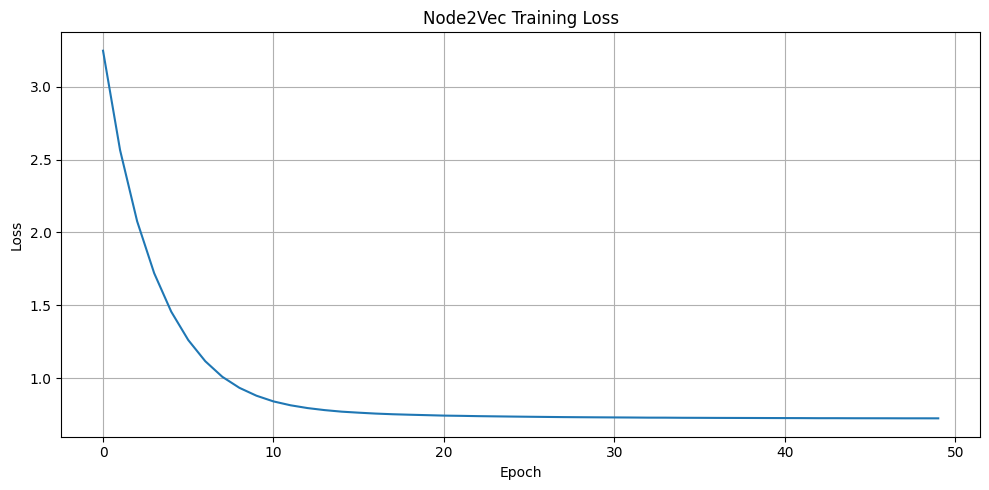

Node2Vec training completed. Final loss: 0.7258
Embeddings shape: torch.Size([1679, 64])


In [15]:
print("Generando embeddings con Node2Vec...")
node_embeddings = train_node2vec(
    data,
    embedding_dim=64,
    walk_length=30,
    num_walks=200,
    p=1,
    q=0.5,
    epochs=50,
    batch_size=128,
    lr=0.01
)

Generando etiquetas para los nodos con tres métodos diferentes...
Generando etiquetas sintéticas usando método: community
Generando etiquetas sintéticas usando método: clustering
Generando etiquetas sintéticas usando método: degree
Etiquetas generadas con éxito.
Número de nodos: 1679
Número de aristas: 1788


/usr/local/lib/python3.11/dist-packages/torch_geometric/data/storage.py:452: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  warnings.warn(


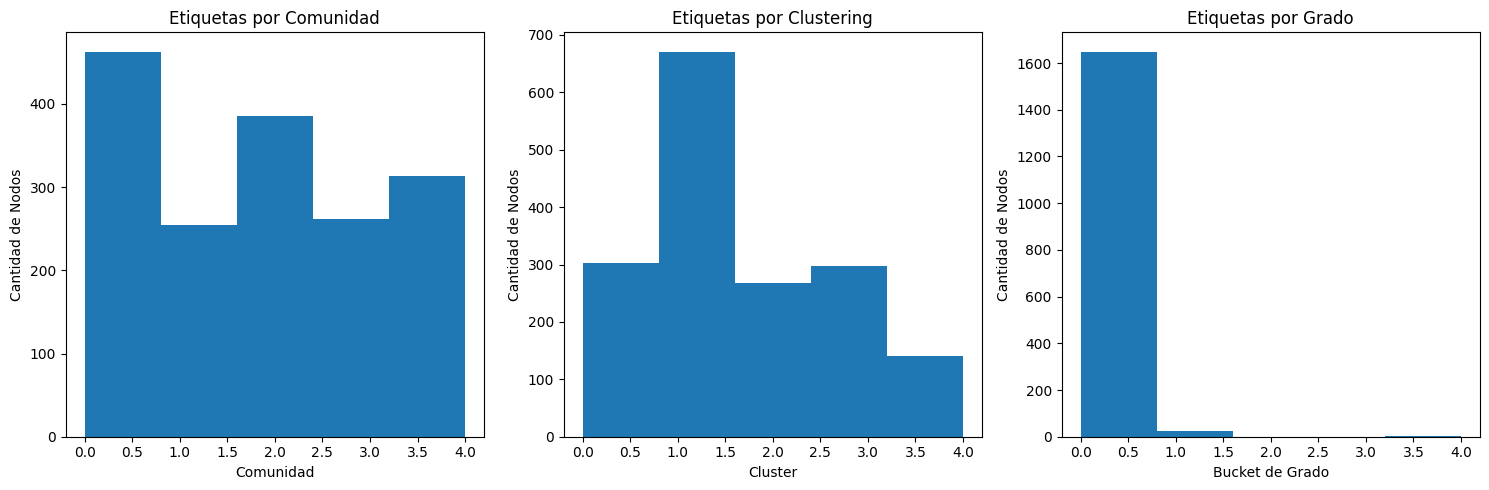

In [16]:
def create_synthetic_node_labels(embeddings=None, edge_index=None, num_nodes=None, method='clustering', n_clusters=5):
    print(f"Generando etiquetas sintéticas usando método: {method}")

    if method == 'clustering' and embeddings is not None:
        embeddings_np = embeddings.detach().cpu().numpy()
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings_np)
        return torch.tensor(labels, dtype=torch.long)

    elif method == 'community' and edge_index is not None:
        temp_data = torch.zeros(num_nodes).reshape(-1, 1)
        temp_data_obj = torch_geometric.data.Data(x=temp_data, edge_index=edge_index)
        G = to_networkx(temp_data_obj, to_undirected=True)
        partition = community_louvain.best_partition(G)
        labels = torch.zeros(num_nodes, dtype=torch.long)
        for node, community_id in partition.items():
            labels[node] = community_id % n_clusters

        return labels

    elif method == 'degree' and edge_index is not None:
        G = to_networkx(torch_geometric.data.Data(edge_index=edge_index), to_undirected=True)
        degrees = dict(G.degree())
        max_degree = max(degrees.values())
        labels = torch.zeros(num_nodes, dtype=torch.long)
        for node, degree in degrees.items():
            bucket = min(int((degree / max_degree) * n_clusters), n_clusters - 1)
            labels[node] = bucket

        return labels

    else:
        print("Usando método aleatorio para generar etiquetas")
        return torch.randint(0, n_clusters, (num_nodes,))

print("Generando etiquetas para los nodos con tres métodos diferentes...")

community_labels = create_synthetic_node_labels(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    method='community',
    n_clusters=5
)

clustering_labels = create_synthetic_node_labels(
    embeddings=node_embeddings,
    method='clustering',
    n_clusters=5
)

degree_labels = create_synthetic_node_labels(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    method='degree',
    n_clusters=5
)

node_labels = community_labels

print("Etiquetas generadas con éxito.")
print(f"Número de nodos: {data.num_nodes}")
print(f"Número de aristas: {data.edge_index.shape[1] // 2}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(community_labels.numpy(), bins=5)
plt.title('Etiquetas por Comunidad')
plt.xlabel('Comunidad')
plt.ylabel('Cantidad de Nodos')

plt.subplot(1, 3, 2)
plt.hist(clustering_labels.numpy(), bins=5)
plt.title('Etiquetas por Clustering')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de Nodos')

plt.subplot(1, 3, 3)
plt.hist(degree_labels.numpy(), bins=5)
plt.title('Etiquetas por Grado')
plt.xlabel('Bucket de Grado')
plt.ylabel('Cantidad de Nodos')

plt.tight_layout()
plt.show()

# **FILTRADO DE NODOS Y PREPARACIÓN DE DATOS**

In [ ]:
def filter_low_degree_nodes(data, node_labels, min_connections=3, negative_samples_ratio=1.0):
    temp_graph = to_networkx(data, to_undirected=True)

    node_degrees = dict(temp_graph.degree())
    nodes_to_keep = [node for node, degree in node_degrees.items() if degree >= min_connections]

    filtered_graph = temp_graph.subgraph(nodes_to_keep)

    print(f"Grafo original: {temp_graph.number_of_nodes()} nodos, {temp_graph.number_of_edges()} aristas")
    print(f"Nodos eliminados: {temp_graph.number_of_nodes() - filtered_graph.number_of_nodes()}")
    print(f"Grafo filtrado: {filtered_graph.number_of_nodes()} nodos, {filtered_graph.number_of_edges()} aristas")

    node_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(filtered_graph.nodes())}

    edge_index = []
    for u, v in filtered_graph.edges():
        edge_index.append([node_mapping[u], node_mapping[v]])
        edge_index.append([node_mapping[v], node_mapping[u]])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t()

    if hasattr(data, 'x') and data.x is not None:
        x = torch.stack([data.x[idx] for idx in nodes_to_keep])
    else:
        x = None

    filtered_labels = torch.stack([node_labels[idx] for idx in nodes_to_keep])
    filtered_data = Data(x=x, edge_index=edge_index)
    filtered_data.num_nodes = filtered_graph.number_of_nodes()

    if negative_samples_ratio > 0:
        num_neg_samples = int(filtered_graph.number_of_edges() * negative_samples_ratio)

        existing_edges = set()
        for u, v in filtered_graph.edges():
            u_mapped = node_mapping[u]
            v_mapped = node_mapping[v]
            existing_edges.add((u_mapped, v_mapped))
            existing_edges.add((v_mapped, u_mapped))
        neg_edge_index = []
        nodes_list = list(range(filtered_data.num_nodes))

        attempts = 0
        max_attempts = num_neg_samples * 10

        while len(neg_edge_index) < num_neg_samples * 2 and attempts < max_attempts:
            u = random.choice(nodes_list)
            v = random.choice(nodes_list)

            if u != v and (u, v) not in existing_edges:
                neg_edge_index.append([u, v])
                neg_edge_index.append([v, u])
                existing_edges.add((u, v))
                existing_edges.add((v, u))

            attempts += 1

        filtered_data.neg_edge_index = torch.tensor(neg_edge_index, dtype=torch.long).t() if neg_edge_index else None
        print(f"Muestras negativas generadas: {len(neg_edge_index) // 2}")

    return filtered_data, filtered_labels, node_mapping

print("Filtrando nodos con menos de 3 conexiones y generando muestras negativas...")
filtered_data, filtered_labels, node_mapping = filter_low_degree_nodes(
    data, node_labels, min_connections=3, negative_samples_ratio=1.0
)

if hasattr(filtered_data, 'neg_edge_index') and filtered_data.neg_edge_index is not None:
    print(f"Número de muestras negativas: {filtered_data.neg_edge_index.shape[1] // 2}")

filtered_data.x = node_embeddings[list(node_mapping.keys())]

num_nodes = filtered_data.num_nodes
train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)

filtered_data.train_mask = torch.zeros(filtered_data.num_nodes, dtype=torch.bool)
filtered_data.val_mask = torch.zeros(filtered_data.num_nodes, dtype=torch.bool)
filtered_data.test_mask = torch.zeros(filtered_data.num_nodes, dtype=torch.bool)

filtered_data.train_mask[:train_size] = True
filtered_data.val_mask[train_size:train_size + val_size] = True
filtered_data.test_mask[train_size + val_size:] = True

print(f"Distribución de nodos:")
print(f"  Entrenamiento: {filtered_data.train_mask.sum().item()} nodos")
print(f"  Validación: {filtered_data.val_mask.sum().item()} nodos")
print(f"  Prueba: {filtered_data.test_mask.sum().item()} nodos")


Filtrando nodos con menos de 3 conexiones y generando muestras negativas...
Grafo original: 1679 nodos, 3575 aristas
Nodos eliminados: 1067
Grafo filtrado: 612 nodos, 2312 aristas
Muestras negativas generadas: 2312
Número de muestras negativas: 2312
Distribución de nodos:
  Entrenamiento: 489 nodos
  Validación: 61 nodos
  Prueba: 62 nodos


Aplicando t-SNE y visualizando embeddings con etiquetas por Comunidad...


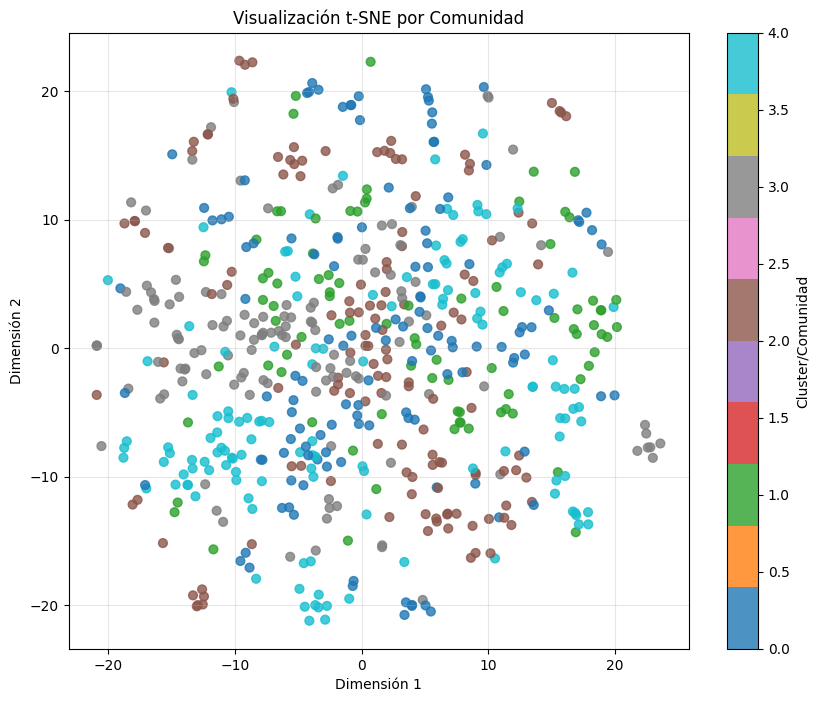

Visualizando grafo con layout spring...


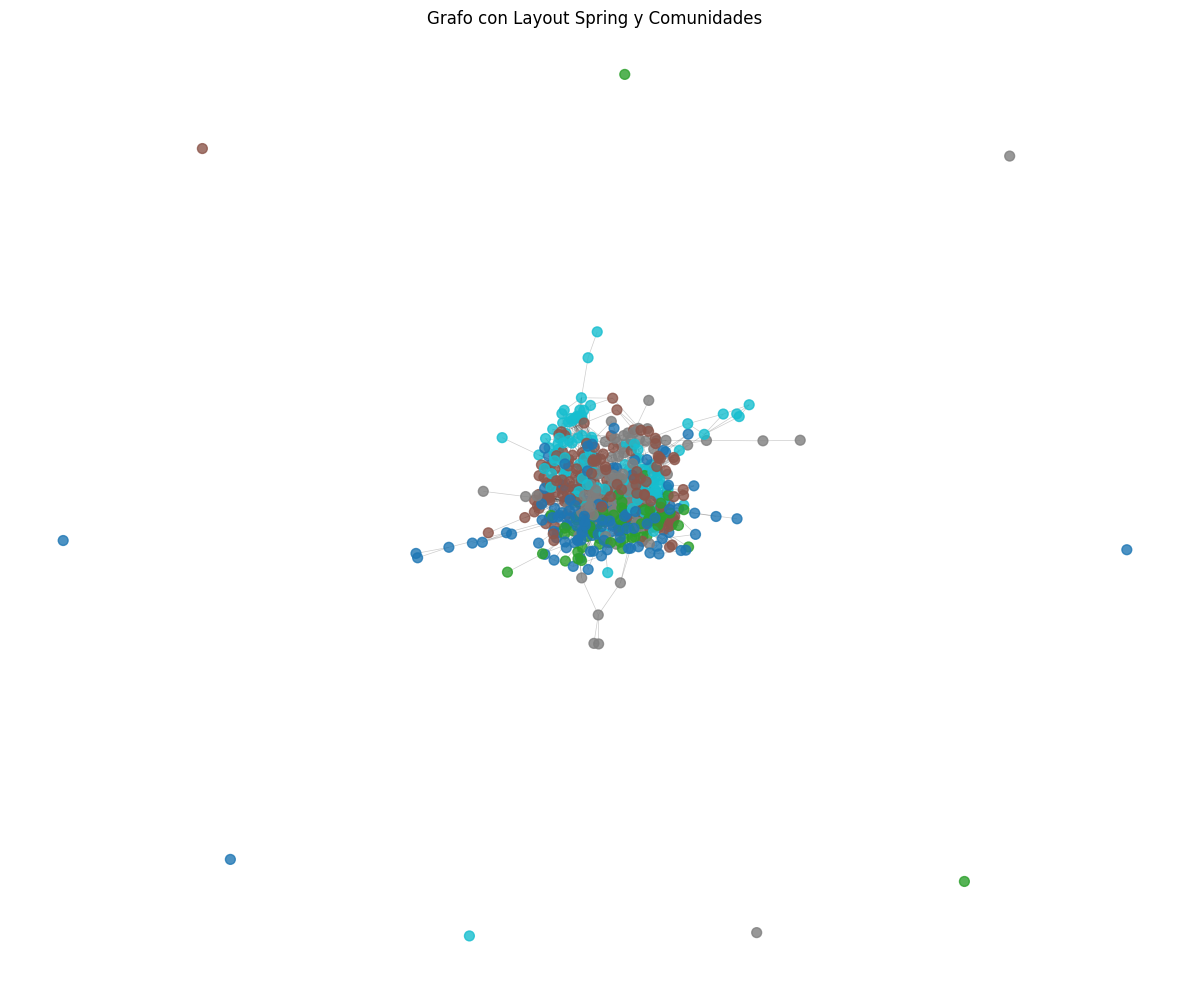

In [18]:
def visualize_embeddings_with_labels(embeddings, labels, title):
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=labels.cpu().numpy(),
        cmap='tab10',
        alpha=0.8,
        s=40
    )
    plt.colorbar(scatter, label='Cluster/Comunidad')
    plt.title(title)
    plt.xlabel('Dimensión 1')
    plt.ylabel('Dimensión 2')
    plt.grid(alpha=0.3)
    plt.show()

    return embeddings_2d

print("Aplicando t-SNE y visualizando embeddings con etiquetas por Comunidad...")
embeddings_2d_community = visualize_embeddings_with_labels(
    filtered_data.x,
    filtered_labels,
    'Visualización t-SNE por Comunidad'
)

def visualize_network(data, node_labels=None, layout='spring', title=None):
    print(f"Visualizando grafo con layout {layout}...")

    temp_data = torch.zeros(data.num_nodes).reshape(-1, 1)
    temp_data_obj = torch_geometric.data.Data(x=temp_data, edge_index=data.edge_index)
    G = to_networkx(temp_data_obj, to_undirected=True)

    if layout == 'spring':
        pos = nx.spring_layout(G, seed=42)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'spectral':
        pos = nx.spectral_layout(G)
    elif layout == 'shell':
        pos = nx.shell_layout(G)
    else:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 10))

    if node_labels is not None:
        node_colors = node_labels.cpu().numpy()
        nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                             node_size=50, alpha=0.8, cmap='tab10')
    else:
        nx.draw_networkx_nodes(G, pos, node_size=50, alpha=0.8)

    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)

    if title:
        plt.title(title)
    else:
        plt.title(f'Visualización de Grafo con Layout {layout.capitalize()}')

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G, pos

G_spring, pos_spring = visualize_network(
    filtered_data,
    node_labels=filtered_labels,
    layout='spring',
    title='Grafo con Layout Spring y Comunidades'
)

# **MODELOS DE CLASIFICACIÓN**

# MLP


Entrenando MLP con los embeddings de Node2Vec...
Entrenando MLP con embeddings de Node2Vec:
  Dimensión de entrada: 64
  Capas ocultas: 128
  Número de clases: 5
  Dropout: 0.5
Época 001: Loss=1.6108, Train=0.3988, Val=0.1148, Test=0.3226
Época 010: Loss=1.2048, Train=0.6278, Val=0.2623, Test=0.4032
Época 020: Loss=0.7532, Train=0.7771, Val=0.4426, Test=0.5323
Época 030: Loss=0.5613, Train=0.8507, Val=0.4098, Test=0.5323
Época 040: Loss=0.4735, Train=0.9202, Val=0.4098, Test=0.5161
Época 050: Loss=0.3932, Train=0.9284, Val=0.3934, Test=0.5323
Época 060: Loss=0.3000, Train=0.9530, Val=0.3934, Test=0.5161
Época 070: Loss=0.2558, Train=0.9611, Val=0.3934, Test=0.5161
Época 080: Loss=0.2214, Train=0.9714, Val=0.3934, Test=0.5161
Época 090: Loss=0.2018, Train=0.9796, Val=0.4098, Test=0.5161
Época 100: Loss=0.1817, Train=0.9816, Val=0.4098, Test=0.5161
Época 110: Loss=0.1810, Train=0.9857, Val=0.3934, Test=0.5161
Época 120: Loss=0.1601, Train=0.9918, Val=0.3934, Test=0.5000
Época 130: Loss=

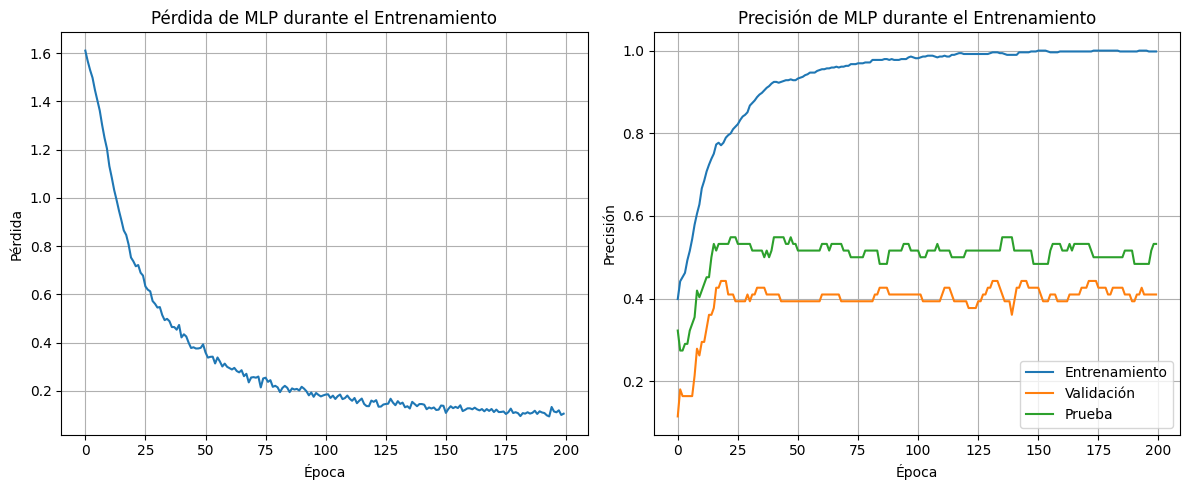

In [30]:
class MLP(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.3):
        super(MLP, self).__init__()
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(in_channels, hidden_channels))

        for _ in range(num_layers - 2):
            self.layers.append(torch.nn.Linear(hidden_channels, hidden_channels))

        self.layers.append(torch.nn.Linear(hidden_channels, out_channels))

        self.dropout = dropout

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.layers[-1](x)
        return F.log_softmax(x, dim=1)

def train_evaluate_mlp(node_embeddings, labels, train_mask, val_mask, test_mask,
                       hidden_channels=128, num_layers=2, dropout=0.5,
                       lr=0.01, weight_decay=5e-4, epochs=200, verbose=True):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    node_embeddings = node_embeddings.detach().clone()

    num_nodes = node_embeddings.shape[0]
    in_channels = node_embeddings.shape[1]
    out_channels = int(labels.max()) + 1

    x = node_embeddings.to(device)
    y = labels.to(device)
    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)
    test_mask = test_mask.to(device)

    model = MLP(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_accs, val_accs, test_accs = [], [], []
    losses = []

    best_val_acc = 0
    best_test_acc = 0

    print(f"Entrenando MLP con embeddings de Node2Vec:")
    print(f"  Dimensión de entrada: {in_channels}")
    print(f"  Capas ocultas: {hidden_channels}")
    print(f"  Número de clases: {out_channels}")
    print(f"  Dropout: {dropout}")

    for epoch in range(1, epochs + 1):
        model.train()
        out = model(x)
        loss = F.nll_loss(out[train_mask], y[train_mask])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            pred = model(x).argmax(dim=1)

            train_correct = pred[train_mask].eq(y[train_mask]).sum().item()
            train_acc = train_correct / train_mask.sum().item()
            train_accs.append(train_acc)

            val_correct = pred[val_mask].eq(y[val_mask]).sum().item()
            val_acc = val_correct / val_mask.sum().item()
            val_accs.append(val_acc)

            test_correct = pred[test_mask].eq(y[test_mask]).sum().item()
            test_acc = test_correct / test_mask.sum().item()
            test_accs.append(test_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc

        if verbose and (epoch % 10 == 0 or epoch == 1 or epoch == epochs):
            print(f'Época {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')

    if verbose:
        print(f"Entrenamiento MLP completado:")
        print(f"  Mejor precisión de validación: {best_val_acc:.4f}")
        print(f"  Precisión de prueba correspondiente: {best_test_acc:.4f}")

    return {
        'model': model,
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_accs': test_accs,
        'losses': losses
    }

print("\nEntrenando MLP con los embeddings de Node2Vec...")
filtered_data.x = filtered_data.x.detach().clone()

try:
    mlp_results = train_evaluate_mlp(
        node_embeddings=filtered_data.x,
        labels=filtered_labels,
        train_mask=filtered_data.train_mask,
        val_mask=filtered_data.val_mask,
        test_mask=filtered_data.test_mask,
        hidden_channels=128,
        num_layers=2,
        dropout=0.5,
        lr=0.01,
        weight_decay=5e-4,
        epochs=200,
        verbose=True
    )
except RuntimeError as e:
    print(f"Error durante el entrenamiento: {e}")
    print("Intentando un enfoque alternativo...")

    # Recreamos completamente todos los datos de entrada
    x_detached = filtered_data.x.detach().clone()
    labels_detached = filtered_labels.clone()
    train_mask_detached = filtered_data.train_mask.clone()
    val_mask_detached = filtered_data.val_mask.clone()
    test_mask_detached = filtered_data.test_mask.clone()

    mlp_results = train_evaluate_mlp(
        node_embeddings=x_detached,
        labels=labels_detached,
        train_mask=train_mask_detached,
        val_mask=val_mask_detached,
        test_mask=test_mask_detached,
        hidden_channels=128,
        num_layers=2,
        dropout=0.5,
        lr=0.01,
        weight_decay=5e-4,
        epochs=200,
        verbose=True
    )

def plot_mlp_performance(mlp_results):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(mlp_results['losses'])
    plt.title('Pérdida de MLP durante el Entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(mlp_results['train_accs'], label='Entrenamiento')
    plt.plot(mlp_results['val_accs'], label='Validación')
    plt.plot(mlp_results['test_accs'], label='Prueba')
    plt.title('Precisión de MLP durante el Entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_mlp_performance(mlp_results)

# **GCN**

Arquitectura del modelo GCN:
GCN(
  (convs): ModuleList(
    (0): GCNConv(64, 128)
    (1): GCNConv(128, 5)
  )
)
Número total de parámetros entrenables: 8965
Optimizador inicializado: Adam con lr=0.01, weight_decay=5e-4
Época 000: Loss=1.6080, Train=0.4029, Val=0.1967, Test=0.2097
Época 010: Loss=1.0375, Train=0.7628, Val=0.5082, Test=0.4839
Época 020: Loss=0.6018, Train=0.8466, Val=0.5246, Test=0.6129
Época 030: Loss=0.4332, Train=0.8753, Val=0.5738, Test=0.6613
Época 040: Loss=0.3499, Train=0.8978, Val=0.6066, Test=0.6774
Época 050: Loss=0.2968, Train=0.9202, Val=0.5902, Test=0.7097
Época 060: Loss=0.2481, Train=0.9305, Val=0.5902, Test=0.7581
Época 070: Loss=0.2316, Train=0.9489, Val=0.6066, Test=0.7581
Época 080: Loss=0.2069, Train=0.9530, Val=0.5574, Test=0.7581
Época 090: Loss=0.1971, Train=0.9571, Val=0.5738, Test=0.7581
Época 100: Loss=0.1844, Train=0.9632, Val=0.5902, Test=0.7419
Época 110: Loss=0.1757, Train=0.9611, Val=0.5574, Test=0.7581
Época 120: Loss=0.1682, Train=0.965

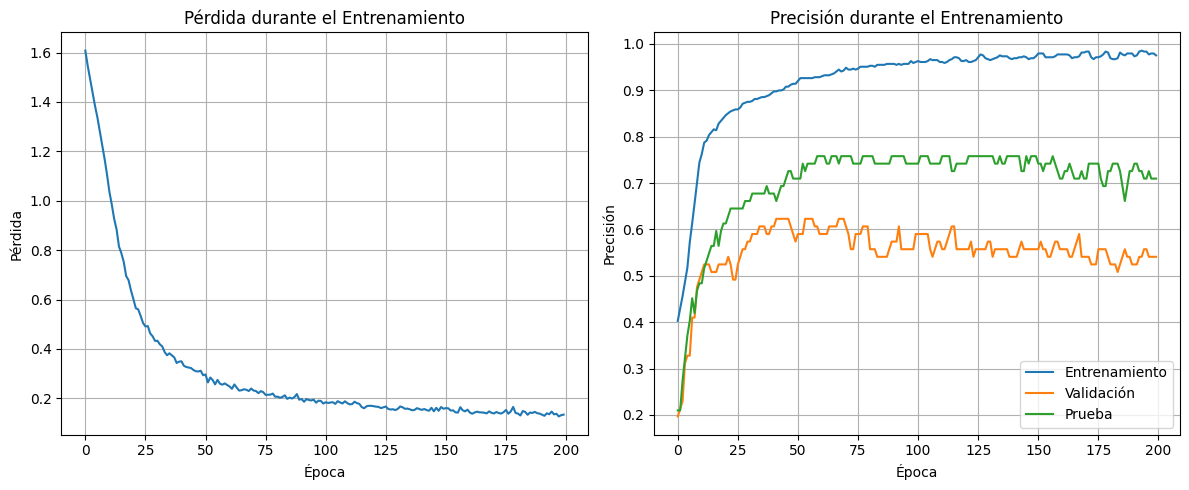

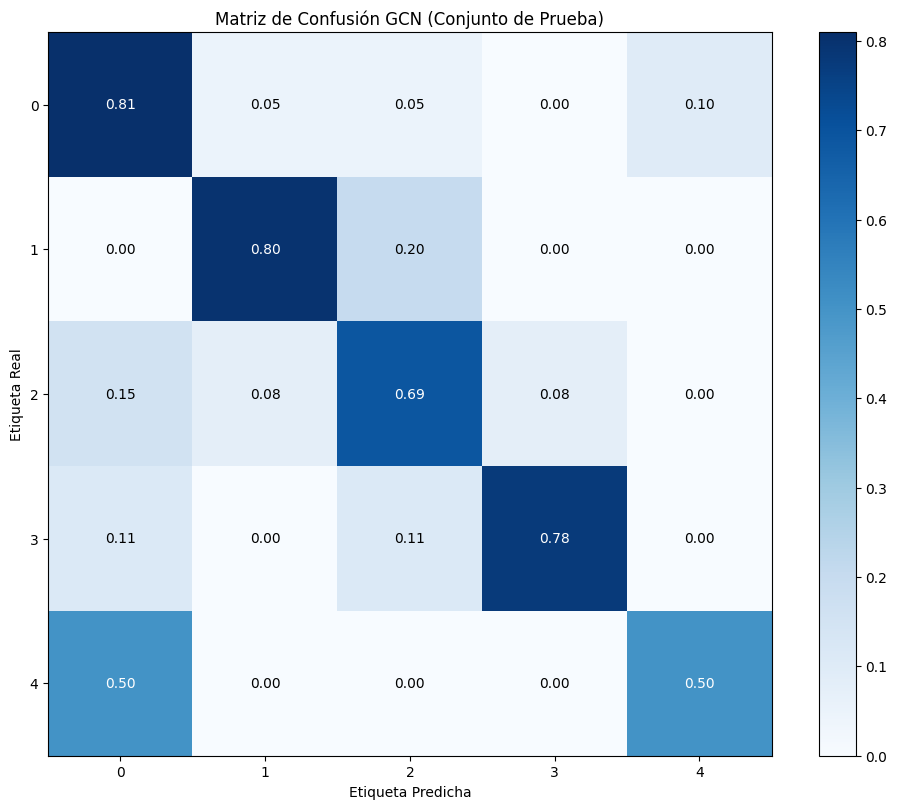

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.3):
        super(GCN, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        self.convs.append(GCNConv(hidden_channels, out_channels))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

gcn_model = GCN(
    in_channels=filtered_data.x.shape[1],
    hidden_channels=128,
    out_channels=5,
    num_layers=2,
    dropout=0.5
)

print("Arquitectura del modelo GCN:")
print(gcn_model)

total_params = sum(p.numel() for p in gcn_model.parameters() if p.requires_grad)
print(f"Número total de parámetros entrenables: {total_params}")

gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)
print("Optimizador inicializado: Adam con lr=0.01, weight_decay=5e-4")

def train_evaluate_gnn(model, optimizer, data, node_labels, num_classes=5, epochs=200, verbose=True):
    model = model.to(device)
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    labels = node_labels.to(device)
    train_mask = data.train_mask.to(device)
    val_mask = data.val_mask.to(device)
    test_mask = data.test_mask.to(device)
    train_accs, val_accs, test_accs = [], [], []
    losses = []

    best_val_acc = 0
    best_test_acc = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(x, edge_index)
        loss = F.nll_loss(out[train_mask], labels[train_mask])

        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            pred = model(x, edge_index).argmax(dim=1)

            train_correct = pred[train_mask].eq(labels[train_mask]).sum().item()
            train_acc = train_correct / train_mask.sum().item()
            train_accs.append(train_acc)
            val_correct = pred[val_mask].eq(labels[val_mask]).sum().item()
            val_acc = val_correct / val_mask.sum().item()
            val_accs.append(val_acc)
            test_correct = pred[test_mask].eq(labels[test_mask]).sum().item()
            test_acc = test_correct / test_mask.sum().item()
            test_accs.append(test_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc

        if verbose and epoch % 10 == 0:
            print(f'Época {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')

    if verbose:
        print(f"Entrenamiento completado:")
        print(f"  Mejor precisión de validación: {best_val_acc:.4f}")
        print(f"  Precisión de prueba correspondiente: {best_test_acc:.4f}")

    return {
        'model': model,
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_accs': test_accs,
        'losses': losses
    }

gcn_results = train_evaluate_gnn(
    gcn_model,
    gcn_optimizer,
    filtered_data,
    filtered_labels,
    num_classes=5,
    epochs=200
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gcn_results['losses'])
plt.title('Pérdida durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(gcn_results['train_accs'], label='Entrenamiento')
plt.plot(gcn_results['val_accs'], label='Validación')
plt.plot(gcn_results['test_accs'], label='Prueba')
plt.title('Precisión durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

def plot_confusion_matrix(model, data, labels, mask, num_classes=5, title='Matriz de Confusión'):
    model.eval()
    with torch.no_grad():
        out = model(data.x.to(device), data.edge_index.to(device))
        pred = out.argmax(dim=1)

        y_true = labels[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()

        cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        plt.figure(figsize=(10, 8))
        plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()

        tick_marks = np.arange(num_classes)
        plt.xticks(tick_marks, range(num_classes))
        plt.yticks(tick_marks, range(num_classes))

        thresh = cm_normalized.max() / 2.
        for i in range(cm_normalized.shape[0]):
            for j in range(cm_normalized.shape[1]):
                plt.text(j, i, f"{cm_normalized[i, j]:.2f}",
                        ha="center", va="center",
                        color="white" if cm_normalized[i, j] > thresh else "black")

        plt.tight_layout()
        plt.ylabel('Etiqueta Real')
        plt.xlabel('Etiqueta Predicha')

        return plt

test_cm_plot = plot_confusion_matrix(
    gcn_results['model'],
    filtered_data,
    filtered_labels,
    filtered_data.test_mask,
    num_classes=5,
    title='Matriz de Confusión GCN (Conjunto de Prueba)'
)
plt.show()


# **GAT**

Modelo GAT inicializado con:
  Características de entrada: 64
  Capas ocultas: 32 con 8 cabezas de atención
  Salida: 5 clases
Entrenando modelo GAT...
Época 000: Loss=1.6188, Train=0.2863, Val=0.1311, Test=0.1935
Época 010: Loss=1.0884, Train=0.7198, Val=0.4262, Test=0.4516
Época 020: Loss=0.8111, Train=0.7975, Val=0.4754, Test=0.5484
Época 030: Loss=0.5940, Train=0.8630, Val=0.4754, Test=0.6452
Época 040: Loss=0.5558, Train=0.8916, Val=0.4754, Test=0.6774
Época 050: Loss=0.4696, Train=0.9080, Val=0.5410, Test=0.6774
Época 060: Loss=0.4056, Train=0.9182, Val=0.5410, Test=0.7097
Época 070: Loss=0.3588, Train=0.9387, Val=0.6393, Test=0.6935
Época 080: Loss=0.3131, Train=0.9509, Val=0.5738, Test=0.7258
Época 090: Loss=0.2989, Train=0.9550, Val=0.5410, Test=0.7419
Época 100: Loss=0.2635, Train=0.9652, Val=0.5738, Test=0.7419
Época 110: Loss=0.2660, Train=0.9714, Val=0.5574, Test=0.7258
Época 120: Loss=0.2487, Train=0.9775, Val=0.5410, Test=0.7258
Época 130: Loss=0.2509, Train=0.9836, Val=

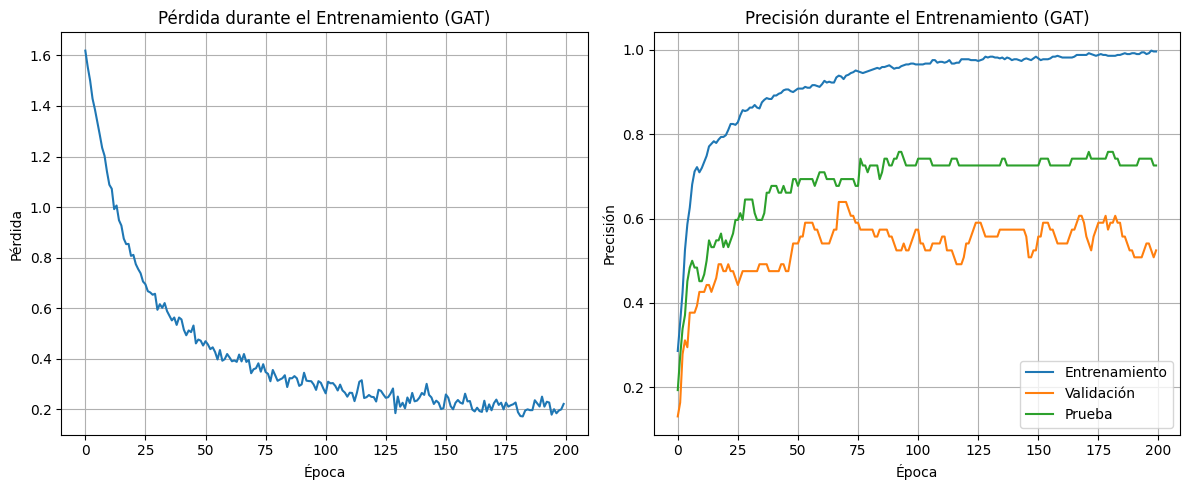

In [32]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, heads=8, dropout=0.6):
        super(GAT, self).__init__()
        self.convs = torch.nn.ModuleList()

        self.convs.append(GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout))

        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout))

        self.convs.append(GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout, concat=False))

        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

gat_model = GAT(
    in_channels=filtered_data.x.shape[1],
    hidden_channels=32,
    out_channels=5,
    num_layers=2,
    heads=8,
    dropout=0.3
)

gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)

print(f"Modelo GAT inicializado con:")
print(f"  Características de entrada: {filtered_data.x.shape[1]}")
print(f"  Capas ocultas: 32 con 8 cabezas de atención")
print(f"  Salida: 5 clases")

print("Entrenando modelo GAT...")
gat_results = train_evaluate_gnn(
    gat_model,
    gat_optimizer,
    filtered_data,
    filtered_labels,
    num_classes=5,
    epochs=200)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gat_results['losses'])
plt.title('Pérdida durante el Entrenamiento (GAT)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(gat_results['train_accs'], label='Entrenamiento')
plt.plot(gat_results['val_accs'], label='Validación')
plt.plot(gat_results['test_accs'], label='Prueba')
plt.title('Precisión durante el Entrenamiento (GAT)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **COMPARATIVA DE RENDIMIENTOS**

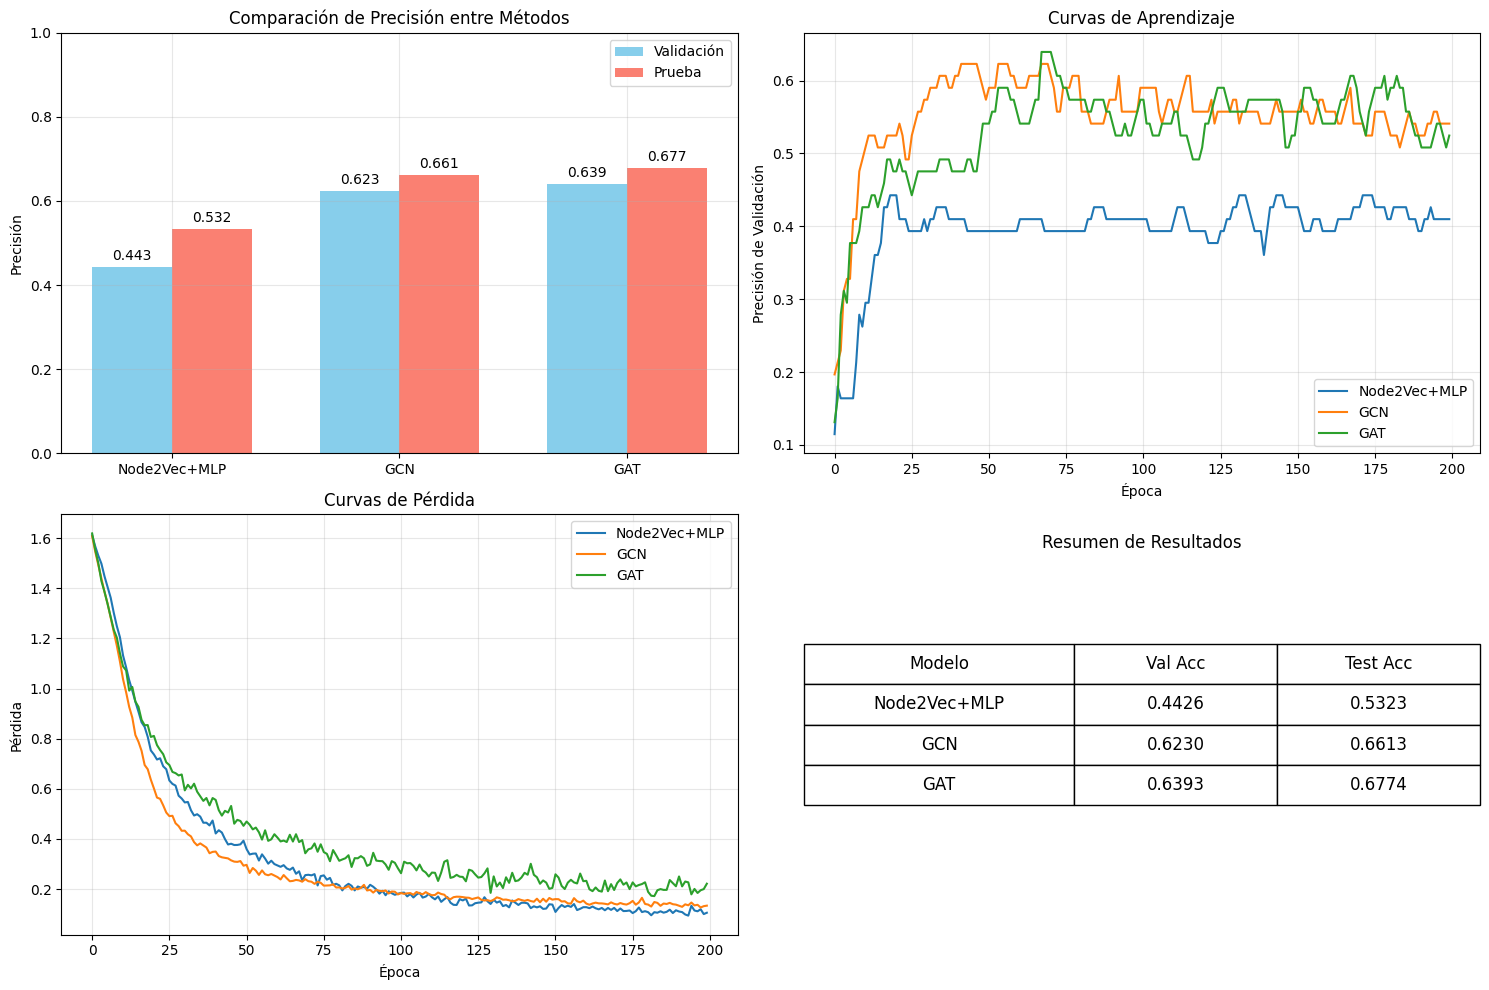

In [33]:
def compare_all_methods(node2vec_mlp_results, gcn_results, gat_results):
    plt.figure(figsize=(15, 10))

    # 1. Comparación de precisión
    plt.subplot(2, 2, 1)
    models = ['Node2Vec+MLP', 'GCN', 'GAT']
    val_accs = [
        node2vec_mlp_results['best_val_acc'],
        gcn_results['best_val_acc'],
        gat_results['best_val_acc']
    ]
    test_accs = [
        node2vec_mlp_results['best_test_acc'],
        gcn_results['best_test_acc'],
        gat_results['best_test_acc']
    ]

    x = range(len(models))
    width = 0.35

    plt.bar([i - width/2 for i in x], val_accs, width, label='Validación', color='skyblue')
    plt.bar([i + width/2 for i in x], test_accs, width, label='Prueba', color='salmon')

    for i, v in enumerate(val_accs):
        plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    for i, v in enumerate(test_accs):
        plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.ylabel('Precisión')
    plt.title('Comparación de Precisión entre Métodos')
    plt.xticks(x, models)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.plot(node2vec_mlp_results['val_accs'], label='Node2Vec+MLP')
    plt.plot(gcn_results['val_accs'], label='GCN')
    plt.plot(gat_results['val_accs'], label='GAT')

    plt.xlabel('Época')
    plt.ylabel('Precisión de Validación')
    plt.title('Curvas de Aprendizaje')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    plt.plot(node2vec_mlp_results['losses'], label='Node2Vec+MLP')
    plt.plot(gcn_results['losses'], label='GCN')
    plt.plot(gat_results['losses'], label='GAT')

    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.title('Curvas de Pérdida')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.axis('off')
    table_data = [
        ['Modelo', 'Val Acc', 'Test Acc'],
        ['Node2Vec+MLP', f"{node2vec_mlp_results['best_val_acc']:.4f}", f"{node2vec_mlp_results['best_test_acc']:.4f}"],
        ['GCN', f"{gcn_results['best_val_acc']:.4f}", f"{gcn_results['best_test_acc']:.4f}"],
        ['GAT', f"{gat_results['best_val_acc']:.4f}", f"{gat_results['best_test_acc']:.4f}"]
    ]

    table = plt.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.4, 0.3, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    plt.title('Resumen de Resultados', y=0.9)

    plt.tight_layout()
    plt.show()

    models_acc = {
        'Node2Vec+MLP': node2vec_mlp_results['best_test_acc'],
        'GCN': gcn_results['best_test_acc'],
        'GAT': gat_results['best_test_acc']
    }

    best_model = max(models_acc.items(), key=lambda x: x[1])

compare_all_methods(mlp_results, gcn_results, gat_results)